In [1]:
#TODO add the case that one transforms the data twice

In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "tu_berlin"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}

repeats = 5
if dataset == "tu_berlin":
    repeats = 10
if dataset == "modelnet10":
    repeats = 10
if dataset == "coil100":
    repeats = 10

architecture = default_architecutre_mapping[dataset]
budget = None

In [3]:
from utils.transforms.apply import grid_resample_border,grid_resample_reflection

In [4]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

Loaded cached TU-Berlin dataset (max_len=200, interpolation_points=2)


In [5]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [6]:
x=next(iter(test_loader_transformed))[0]

In [7]:
batch_size = next(iter(train_loader))[0].shape[0]


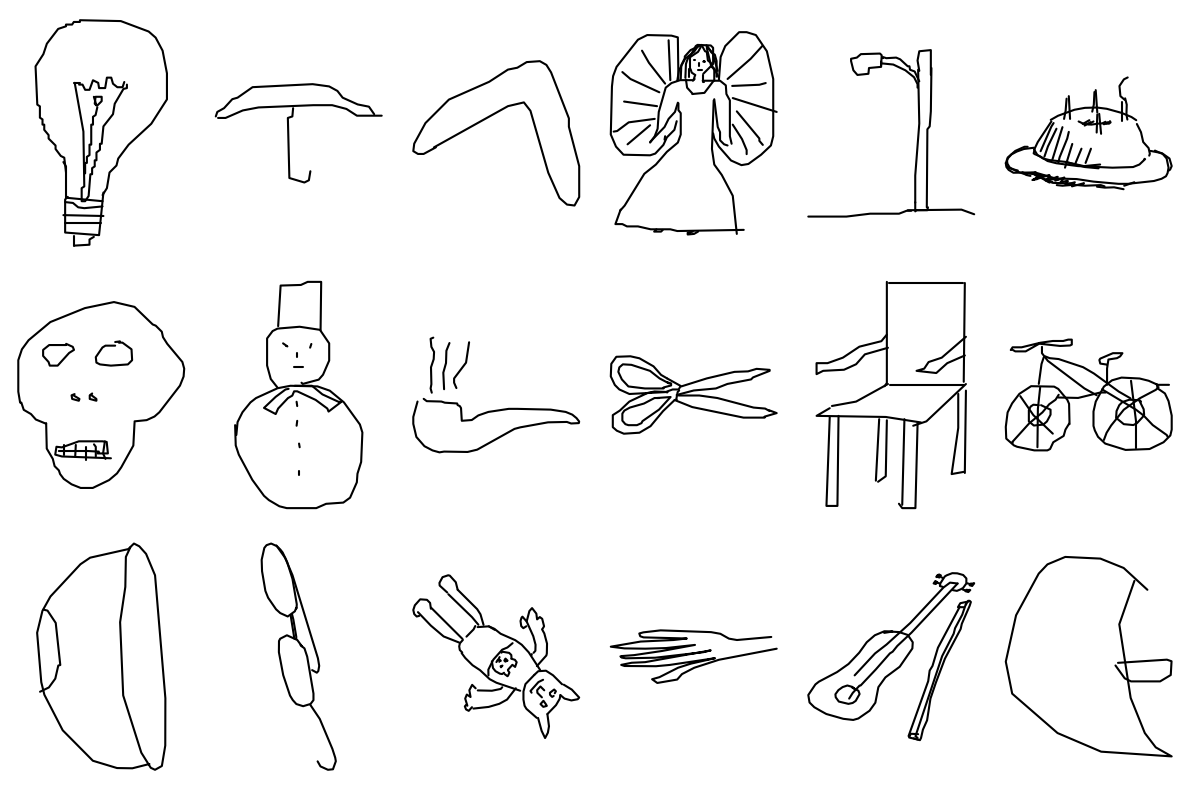

In [8]:
from utils.eval.vis import vis_dataset, plt_setup_latex

vis_dataset(train_loader,val_loader,test_loader_transformed)

In [9]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network, StrokeAugment
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_supervised_methods")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

In [10]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)

modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm.safetensors


(BILSTMSKETCHClassifier(
   (preprocess): NormalizeToRangeBatched()
   (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
   (attention): Linear(in_features=512, out_features=1, bias=False)
   (attn_dropout): Dropout(p=0.2, inplace=False)
   (augmentation): StrokeAugment()
   (classifier): Sequential(
     (0): Linear(in_features=512, out_features=512, bias=True)
     (1): GELU(approximate='none')
     (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
     (3): Dropout(p=0.5, inplace=False)
     (4): Linear(in_features=512, out_features=250, bias=True)
   )
 ),
 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models\\tu_berlin_bi_lstm.safetensors')

In [11]:
model.eval().to(device)

BILSTMSKETCHClassifier(
  (preprocess): NormalizeToRangeBatched()
  (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=False)
  (attn_dropout): Dropout(p=0.2, inplace=False)
  (augmentation): StrokeAugment()
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=250, bias=True)
  )
)

In [12]:
#chek if data is image data
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

In [13]:
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]





from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)
from utils.replacer import replace_rotation_transforms_2vec

if dataset == "modelnet10":
    transform_seq = replace_rotation_transforms_2vec(transform_seq)

In [14]:

transform_seq_non_sobol = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
).to(device)

transform_seq_sobol = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)


In [15]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 0, num_classes=None, num_rotations=8)

In [16]:
from confidence.direct.logit_based import EnergyConfidence
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence

logit_energy = SinglePassConfidence(model, EnergyConfidence(), index=None)
problem_energy_logits = TransformationProblem(logit_energy, transform_seq,                                              consolidate_method="consolidate_simple")
#test ot
from search.shgo import SHGO
optimizer = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,local_opt_kwargs={"lr":0.1})
if dataset == "tu_berlin":
    optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})


from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search, evaluate_confidence_and_search, \
    ITSWRAPPER


In [17]:
res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_confidence_transformed"), show_progress=True,
    repeats=repeats)

In [18]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [19]:
if dataset=="modelnet10":
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    def test_rotation_sampling(transform, n_samples=100000, domain=None):
        """Test and visualize rotation sampling distribution."""

        # Method 1: sample_param (individual)
        params_individual = transform.sample_param(batch_size=n_samples, domain=domain, device="cpu")

        # Method 2: sobol_to_param
        sobol_engine = torch.quasirandom.SobolEngine(dimension=3)
        sobol_samples = sobol_engine.draw(n_samples)
        params_sobol = transform.sobol_to_param(sobol_samples, domain)

        # Convert to rotation matrices and extract angles
        matrices_individual = transform.matrix(params_individual)
        matrices_sobol = transform.matrix(params_sobol)

        # Calculate rotation angles from trace
        def get_rotation_angles(matrices):
            traces = torch.einsum('...ii->...', matrices[..., :3, :3])
            cos_theta = torch.clamp((traces - 1.0) / 2.0, -1.0, 1.0)
            return torch.acos(cos_theta)

        angles_individual = get_rotation_angles(matrices_individual).numpy()
        angles_sobol = get_rotation_angles(matrices_sobol).numpy()

        # Theoretical PDF for uniform SO(3): (1/π)(1 - cos(θ))
        theta_range = np.linspace(0, np.pi, 200)
        pdf_theoretical = (1.0 / np.pi) * (1.0 - np.cos(theta_range))

        # Plot comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Individual sampling
        ax1.hist(angles_individual, bins=100, density=True, alpha=0.7, label='sample_param')
        ax1.plot(theta_range, pdf_theoretical, 'r-', linewidth=2, label='Theoretical SO(3)')
        ax1.set_xlabel(r'Rotation Angle (radians)')
        ax1.set_ylabel('Probability Density')
        ax1.set_title(f'{transform.__class__.__name__} - sample_param')
        ax1.legend()
        ax1.grid(True)

        # Sobol sampling
        ax2.hist(angles_sobol, bins=100, density=True, alpha=0.7, label='sobol_to_param')
        ax2.plot(theta_range, pdf_theoretical, 'r-', linewidth=2, label='Theoretical SO(3)')
        ax2.set_xlabel(r'Rotation Angle (radians)')
        ax2.set_ylabel('Probability Density')
        ax2.set_title(f'{transform.__class__.__name__} - sobol_to_param')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

        # Statistical test
        print(f"\n{transform.__class__.__name__} Statistics:")
        print(f"sample_param - Mean angle: {angles_individual.mean():.4f}, Std: {angles_individual.std():.4f}")
        print(f"sobol_to_param - Mean angle: {angles_sobol.mean():.4f}, Std: {angles_sobol.std():.4f}")

    # Test both transforms
    from utils.transforms.rotation import Rotation3DEulerUniform, Rotation2Vec

    # To this (create an instance):
    test_rotation_sampling(Rotation3DEulerUniform(), n_samples=50000)

    test_rotation_sampling(Rotation2Vec(), n_samples=50000)

In [20]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

@torch.no_grad()
def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    multiple_augment = utils.augments.build_default_augmentations()
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None
    multiple_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=multiple_augment,
    decision_strategy=dec_strat,
)

energy_conf_default = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy2", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

energy_conf_default.to(device).eval()



problem_energy_default = TransformationProblem(energy_conf_default, transform_seq,                                              consolidate_method="consolidate_simple")

res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_default,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed"), show_progress=True,
    repeats=repeats)

#unload values
del energy_model2
del energy_conf_default
del problem_energy_default
print(res)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy2_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 20, 'accuracy_mean': 0.2859500050544739, 'accuracy_std': 0.009199395775794983, 'accuracy_se': 0.0020570474306601996, 'f2_macro_mean': 0.27847886085510254, 'f2_macro_std': 0.009961415082216263, 'f2_macro_se': 0.0022274401275927218, 'f2_micro_mean': 0.2859500050544739, 'f2_micro_std': 0.009199395775794983, 'f2_micro_se': 0.0020570474306601996, 'f2_weighted_mean': 0.28097859025001526, 'f2_weighted_std': 0.009438939392566681, 'f2_weighted_se': 0.002110611011727967, 'per_run': [{'accuracy': 0.2919999957084656, 'f2_macro': 0.28663501143455505, 'f2_micro': 0.2919999957084656, 'f2_weighted': 0.2876991629600525, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accuracy': 0.29850000

In [21]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

@torch.no_grad()
def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    multiple_augment = utils.augments.build_default_augmentations()
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None
    multiple_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=multiple_augment,
    decision_strategy=dec_strat,
)

energy_conf_default = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy7", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

energy_conf_default.to(device).eval()



problem_energy_default = TransformationProblem(energy_conf_default, transform_seq,                                              consolidate_method="consolidate_simple")

res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_default,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed7"), show_progress=True,
    repeats=repeats)

#unload values
del energy_model2
del energy_conf_default
del problem_energy_default
print(res)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy7_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 10, 'accuracy_mean': 0.2802000045776367, 'accuracy_std': 0.008327331393957138, 'accuracy_se': 0.0026333334035929467, 'f2_macro_mean': 0.273746132850647, 'f2_macro_std': 0.007487267255783081, 'f2_macro_se': 0.0023676817978673043, 'f2_micro_mean': 0.2802000045776367, 'f2_micro_std': 0.008327331393957138, 'f2_micro_se': 0.0026333334035929467, 'f2_weighted_mean': 0.2765825390815735, 'f2_weighted_std': 0.00857082474976778, 'f2_weighted_se': 0.002710332763540889, 'per_run': [{'accuracy': 0.26249998807907104, 'f2_macro': 0.2590493857860565, 'f2_micro': 0.26249998807907104, 'f2_weighted': 0.25874751806259155, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accuracy': 0.2775000035

In [22]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

@torch.no_grad()
def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)
print(energy_model2.aug)
energy_model2.aug = False

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    multiple_augment = utils.augments.build_default_augmentations()
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None
    multiple_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=multiple_augment,
    decision_strategy=dec_strat,
)

energy_conf_default = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy222", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

energy_conf_default.to(device).eval()



problem_energy_default = TransformationProblem(energy_conf_default, transform_seq,                                              consolidate_method="consolidate_simple")

res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_default,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed222"), show_progress=True,
    repeats=repeats)

#unload values
del energy_model2
del energy_conf_default
del problem_energy_default
print(res)


True
Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy222_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 10, 'accuracy_mean': 0.27570000290870667, 'accuracy_std': 0.007881766185164452, 'accuracy_se': 0.0024924333130016095, 'f2_macro_mean': 0.2701219916343689, 'f2_macro_std': 0.007254279218614101, 'f2_macro_se': 0.00229400451136471, 'f2_micro_mean': 0.27570000290870667, 'f2_micro_std': 0.007881766185164452, 'f2_micro_se': 0.0024924333130016095, 'f2_weighted_mean': 0.2710268199443817, 'f2_weighted_std': 0.007997648790478706, 'f2_weighted_se': 0.002529078610400347, 'per_run': [{'accuracy': 0.265500009059906, 'f2_macro': 0.2598237693309784, 'f2_micro': 0.265500009059906, 'f2_weighted': 0.259307861328125, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accuracy': 0.2849999

In [23]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

@torch.no_grad()
def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)
energy_model2.aug = False

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    multiple_augment = utils.augments.build_default_augmentations()
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None
    multiple_augment = None
    if dataset =="tu_berlin":
        affine_augment = StrokeAugment()

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)

energy_conf_default = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy777", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

energy_conf_default.to(device).eval()



problem_energy_default = TransformationProblem(energy_conf_default, transform_seq,                                              consolidate_method="consolidate_simple")

res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_default,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed777"), show_progress=True,
    repeats=repeats)

#unload values
del energy_model2
del energy_conf_default
del problem_energy_default
print(res)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy777_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 10, 'accuracy_mean': 0.27560001611709595, 'accuracy_std': 0.009671836160123348, 'accuracy_se': 0.0030585031421966782, 'f2_macro_mean': 0.26678162813186646, 'f2_macro_std': 0.010411210358142853, 'f2_macro_se': 0.0032923137930868773, 'f2_micro_mean': 0.27560001611709595, 'f2_micro_std': 0.009671836160123348, 'f2_micro_se': 0.0030585031421966782, 'f2_weighted_mean': 0.2704465687274933, 'f2_weighted_std': 0.008742080070078373, 'f2_weighted_se': 0.0027644884509012055, 'per_run': [{'accuracy': 0.2865000069141388, 'f2_macro': 0.277881383895874, 'f2_micro': 0.2865000069141388, 'f2_weighted': 0.2806319296360016, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accuracy': 0.277000

In [24]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

@torch.no_grad()
def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    multiple_augment = utils.augments.build_default_augmentations()
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None
    multiple_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=multiple_augment,
    decision_strategy=dec_strat,
)

energy_conf_default = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy2_det", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True,deterministic_val=True)

energy_conf_default.to(device).eval()



problem_energy_default = TransformationProblem(energy_conf_default, transform_seq,                                              consolidate_method="consolidate_simple")

res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_default,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed_det"), show_progress=True,
    repeats=repeats)

#unload values
del energy_model2
del energy_conf_default
del problem_energy_default
print(res)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy2_det_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 10, 'accuracy_mean': 0.284199982881546, 'accuracy_std': 0.008230026811361313, 'accuracy_se': 0.002602562992815468, 'f2_macro_mean': 0.2757217586040497, 'f2_macro_std': 0.008168449625372887, 'f2_macro_se': 0.0025830905768527445, 'f2_micro_mean': 0.284199982881546, 'f2_micro_std': 0.008230026811361313, 'f2_micro_se': 0.002602562992815468, 'f2_weighted_mean': 0.27962902188301086, 'f2_weighted_std': 0.008239949122071266, 'f2_weighted_se': 0.002605700702965001, 'per_run': [{'accuracy': 0.26600000262260437, 'f2_macro': 0.25899025797843933, 'f2_micro': 0.26600000262260437, 'f2_weighted': 0.2617757320404053, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accuracy': 0.2834999

In [25]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

if dataset =="modelnet10":
    @torch.no_grad()
    def dec_strat_model(x, idd, y_true):
        make_deterministic(model, random=True,verbose=False)
        out = model(x)
        make_deterministic(model,random=False,verbose=False)
        eq = out.argmax(dim=-1) == y_true
        #convert to tensor where y>=0 if correct, y<0 if incorrect
        y = torch.where(eq, y_true, -1)
        return y

    from utils.augments import build_default_augmentations, small_affine_augment_2d
    from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
    import importlib
    import utils.sampling_strategy
    import utils.sampling

    importlib.reload(utils.sampling)
    from utils.sampling import BatchNegativeSampler


    energy_model4 = get_network(dataset_info,architecture, num_classes=1).to(device)

    from experiment_thesis.main import train_or_load_energy_model

    if is_image_data:
        transform_true_function = small_affine_augment_2d
        multiple_augment = utils.augments.build_default_augmentations()
        affine_augment = ComposeAugmentations([
            lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                             blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                             usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                             usm_amount_range=(0.5, 1.3), clamp=True),

        ])
    else:
        transform_true_function = None
        affine_augment = None
        multiple_augment = None

    negative_sampling_module = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=multiple_augment,
        decision_strategy=dec_strat_model,
    )

    energy_conf_default = train_or_load_energy_model(
        energy_model4, model_dir_path, f"{modelname}_energy4", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

    energy_conf_default.to(device).eval()



    problem_energy_default = TransformationProblem(energy_conf_default, transform_seq,                                              consolidate_method="consolidate_simple")

    res=load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_default,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_transformed4"), show_progress=True,
        repeats=repeats)

    #unload values
    del energy_model4
    del energy_conf_default
    del problem_energy_default
    print(res)


In [26]:
W =plt_setup_latex()

In [27]:
figure_path = os.path.join(current_path,"experiment_files","export","fig","comparision_supervised",dataset,transform_name)
os.makedirs(figure_path, exist_ok=True)

In [28]:
if is_image_data:
    x = next(iter(test_loader))[0]
    #take only 72
    x =x[:72]

    x_aug = transform_true_function(x)
    dif = (x - x_aug).abs()

    fig, axs = plt.subplots(1, 3, figsize=(W,W/2))  # 1 row, 3 columns

    # Original
    axs[0].set_title("Original")
    axs[0].imshow(torchvision.utils.make_grid(x, nrow=8).cpu().permute(1,2,0))
    axs[0].axis("off")

    # Augmented
    axs[1].set_title("Augmented")
    axs[1].imshow(torchvision.utils.make_grid(x_aug, nrow=8).cpu().permute(1,2,0))
    axs[1].axis("off")

    # Difference
    axs[2].set_title("Difference")
    axs[2].imshow(torchvision.utils.make_grid(dif, nrow=8).cpu().permute(1,2,0))
    axs[2].axis("off")


    plt.tight_layout()
    plt.savefig(os.path.join(figure_path,"true_augmentations.png"), dpi=300)


    plt.show()


In [29]:
if is_image_data:
    x = next(iter(test_loader))[0]
    #take only 72
    x =x[:72]

    x_aug = affine_augment(x)
    dif = (x - x_aug).abs()

    fig, axs = plt.subplots(1, 3, figsize=(W,W/2))  # 1 row, 3 columns

    # Original
    axs[0].set_title("Original")
    axs[0].imshow(torchvision.utils.make_grid(x, nrow=8).cpu().permute(1,2,0))
    axs[0].axis("off")

    # Augmented
    axs[1].set_title("Augmented")
    axs[1].imshow(torchvision.utils.make_grid(x_aug, nrow=8).cpu().permute(1,2,0))
    axs[1].axis("off")

    # Difference
    axs[2].set_title("Difference")
    axs[2].imshow(torchvision.utils.make_grid(dif, nrow=8).cpu().permute(1,2,0))
    axs[2].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(figure_path,"affine_augmentations.png"), dpi=300)
    plt.show()


In [30]:
#if image data also test a variant without augmentations
if is_image_data:
    energy_model_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug), model_dir_path, f"{modelname}_energy2_no_aug", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True)
    energy_conf_no_aug.to(device).eval()
    problem_energy_no_aug = TransformationProblem(energy_conf_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_no_aug_transformed"), show_progress=True,
        repeats=repeats)

    #unload values
    del energy_model_no_aug
    del energy_conf_no_aug
    del problem_energy_no_aug
    print(res)

In [50]:
#if image data also test a variant with only blur augmentations
if is_image_data or dataset=="tu_berlin":
    print("affine_augment")
    energy_model_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, mode="double_resampled"), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug), model_dir_path, f"{modelname}_energy2_only_blur_aug_double_rs", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True)
    energy_conf_no_aug.to(device).eval()
    problem_energy_no_aug = TransformationProblem(energy_conf_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_double_rs"), show_progress=True,
        repeats=repeats)

    #unload values
    del energy_model_no_aug
    del energy_conf_no_aug
    del problem_energy_no_aug
    print(res)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


affine_augment
Model has non-negative constraint: False


wandb: Currently logged in as: batschbirne (hasenparty) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                   | Params | Mode 
----------------------------------------------------------------------------
0 | negative_sampling_module | BatchNegativeSampler   | 0      | train
1 | feature_extractor        | Identity               | 0      | eval 
2 | energy_model             | BILSTMSKETCHClassifier | 2.4 M  | train
----------------------------------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total params
9.505     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 24, global step 3125: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=25` reached.


Best Lightning checkpoint: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\checkpoints\tu_berlin_bi_lstm_energy2_only_blur_aug_double_rs_energy_conf_best-v1.ckpt
Model has non-negative constraint: False
Best model weights saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy2_only_blur_aug_double_rs_energy_conf_best.safetensors



Eval (all repeats): 100%|██████████| 160/160 [03:36<00:00,  1.35s/it, Acc=0.278]


{'repeats': 10, 'accuracy_mean': 0.27205002307891846, 'accuracy_std': 0.008619903586804867, 'accuracy_se': 0.0027258528545358314, 'f2_macro_mean': 0.2661952078342438, 'f2_macro_std': 0.008647534064948559, 'f2_macro_se': 0.002734590378913188, 'f2_micro_mean': 0.27205002307891846, 'f2_micro_std': 0.008619903586804867, 'f2_micro_se': 0.0027258528545358314, 'f2_weighted_mean': 0.26661616563796997, 'f2_weighted_std': 0.008285952731966972, 'f2_weighted_se': 0.0026202483217510307, 'per_run': [{'accuracy': 0.2784999907016754, 'f2_macro': 0.27262747287750244, 'f2_micro': 0.2784999907016754, 'f2_weighted': 0.2731650471687317, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accuracy': 0.27799999713897705, 'f2_macro': 0.2686747908592224, 'f2_micro': 0.27799999713897705, 'f2_weighted': 0.2711392641067505, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_

In [32]:
#test negative_sampling_module_no_aug by drawing from it
# x = next(iter(train_loader))[0].to(device)
# y = next(iter(train_loader))[1].to(device)
# neg_samples, y = negative_sampling_module_no_aug((x, y))
# plt.figure(figsize=(W*2,W))
# plt.imshow(torchvision.utils.make_grid(neg_samples, nrow=8).cpu().permute(1,2,0))

In [33]:
#if image data also test a variant with only blur augmentations
if is_image_data:
    energy_model_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug), model_dir_path, f"{modelname}_energy2_only_blur_aug", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True)
    energy_conf_no_aug.to(device).eval()
    problem_energy_no_aug = TransformationProblem(energy_conf_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed"), show_progress=True,
        repeats=repeats)

    #unload values
    del energy_model_no_aug
    del energy_conf_no_aug
    del problem_energy_no_aug
    print(res)

In [34]:
#if image data also test a variant without augmentations
if is_image_data:
    energy_model_true_aug_only = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_true_aug_only = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=None,
        decision_strategy=dec_strat,
    )
    energy_conf_true_aug_only = train_or_load_energy_model(
        copy.deepcopy(energy_model_true_aug_only), model_dir_path, f"{modelname}_energy2_true_aug_only", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_true_aug_only, load_if_exists=True)
    energy_conf_true_aug_only.to(device).eval()
    problem_energy_true_aug_only = TransformationProblem(energy_conf_true_aug_only, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_true_aug_only,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_true_aug_only_transformed"), show_progress=True,
        repeats=repeats)
    #unload values
    del energy_model_true_aug_only
    del energy_conf_true_aug_only
    del problem_energy_true_aug_only
    print(res)

In [35]:
if is_image_data:
    energy_model_no_true_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_true_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )
    energy_conf_no_true_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_true_aug), model_dir_path, f"{modelname}_energy2_no_true_aug", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_true_aug, load_if_exists=True)
    energy_conf_no_true_aug.to(device).eval()
    problem_energy_no_true_aug = TransformationProblem(energy_conf_no_true_aug, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_true_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_no_true_aug_transformed"), show_progress=True,
        repeats=repeats)
    #unload values
    del energy_model_no_true_aug
    del energy_conf_no_true_aug
    del problem_energy_no_true_aug
    print(res)

In [36]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if is_image_data:
    res_all_augment = json.load(open(savepath("learned_energy_confidence_transformed"), "r"))
    res_no_augment = json.load(open(savepath("learned_energy_confidence_no_aug_transformed"), "r"))
    res_blur_augment = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed"), "r"))
    res_true_augment_only = json.load(open(savepath("learned_energy_confidence_true_aug_only_transformed"), "r"))
    res_blur_no_true = json.load(open(savepath("learned_energy_confidence_no_true_aug_transformed"), "r"))

    # Prepare data
    augment_types = [
        "No Augment",
        "True",
        "Blur",
        "Both",
        "Additional"
    ]
    means = [
        res_no_augment['accuracy_mean'],
        res_true_augment_only['accuracy_mean'],
        res_blur_no_true['accuracy_mean'],
        res_blur_augment['accuracy_mean'],
        res_all_augment['accuracy_mean']
    ]
    ses = [
        res_no_augment.get('accuracy_se', 0),
        res_true_augment_only.get('accuracy_se', 0),
        res_blur_no_true.get('accuracy_se', 0),
        res_blur_augment.get('accuracy_se', 0),
        res_all_augment.get('accuracy_se', 0)
    ]
    ses = np.array(ses)*1.96

    # Plotting
    plt.figure(figsize=(W,W*0.5))
    ax = sns.barplot(x=augment_types, y=means, palette="tab10")

    # Add error bars
    ax.errorbar(x=np.arange(len(augment_types)), y=means, yerr=ses, fmt='none', c='black', capsize=5)


    # Dynamic y-limits based on mean ± SE
    ymin = min([m - s for m, s in zip(means, ses)]) - 0.05
    ymax = max([m + s for m, s in zip(means, ses)]) + 0.05
    ax.set_ylim(ymin, ymax)

    ax.set_ylabel("Accuracy")
    #plt.title("Comparison of Different Augmentation Strategies")
    plt.savefig(os.path.join(figure_path,"augmentation_strategies_comparison.pgf"), dpi=300)
    plt.savefig(os.path.join(figure_path,"augmentation_strategies_comparison.pdf"))
    plt.show()


In [37]:
#now test the variant that uses no dec strat
energy_model_no_dec_strat = get_network(dataset_info,architecture, num_classes=1).to(device)
negative_sampling_module_no_dec_strat = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=None,
)
energy_conf_no_dec_strat = train_or_load_energy_model(
    copy.deepcopy(energy_model_no_dec_strat), model_dir_path, f"{modelname}_energy2_no_dec_strat", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module_no_dec_strat, load_if_exists=True)
energy_conf_no_dec_strat.to(device).eval()
problem_energy_no_dec_strat = TransformationProblem(energy_conf_no_dec_strat, transform_seq,                                              consolidate_method="consolidate_simple")
res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_no_dec_strat,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_no_dec_strat_transformed"), show_progress=True,
    repeats=repeats)
del energy_model_no_dec_strat
del energy_conf_no_dec_strat
del problem_energy_no_dec_strat
print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy2_no_dec_strat_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 10, 'accuracy_mean': 0.23045000433921814, 'accuracy_std': 0.0074961078353226185, 'accuracy_se': 0.0023704774345853865, 'f2_macro_mean': 0.22595874965190887, 'f2_macro_std': 0.009670717641711235, 'f2_macro_se': 0.003058149435617967, 'f2_micro_mean': 0.23045000433921814, 'f2_micro_std': 0.0074961078353226185, 'f2_micro_se': 0.0023704774345853865, 'f2_weighted_mean': 0.2262926995754242, 'f2_weighted_std': 0.007924774661660194, 'f2_weighted_se': 0.002506033787443646, 'per_run': [{'accuracy': 0.23749999701976776, 'f2_macro': 0.23530171811580658, 'f2_micro': 0.23749999701976776, 'f2_weighted': 0.2327214777469635, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accu

In [38]:
#now no dec strat no augmentations
if is_image_data:
    energy_model_no_dec_strat_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_dec_strat_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=None,
    )
    energy_conf_no_dec_strat_no_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_dec_strat_no_aug), model_dir_path, f"{modelname}_energy2_no_dec_strat_no_aug", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_dec_strat_no_aug, load_if_exists=True)
    energy_conf_no_dec_strat_no_aug.to(device).eval()
    problem_energy_no_dec_strat_no_aug = TransformationProblem(energy_conf_no_dec_strat_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_dec_strat_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_no_dec_strat_no_aug_transformed"), show_progress=True,
        repeats=repeats)
    del energy_model_no_dec_strat_no_aug
    del energy_conf_no_dec_strat_no_aug
    del problem_energy_no_dec_strat_no_aug
    print(res)


C:\Users\Lindner\AppData\Local\Temp\ipykernel_30960\403043031.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=loss_types, y=means, palette="tab10")


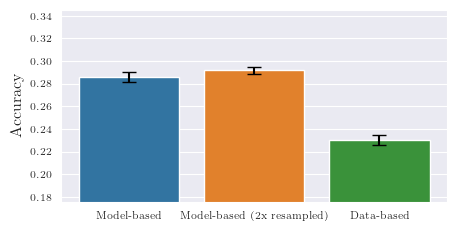

In [39]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if is_image_data:
    res_blur_augment = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed"), "r"))
    res_no_dec_strat = json.load(open(savepath("learned_energy_confidence_no_dec_strat_transformed"), "r"))
    res_no_dec_strat_no_aug = json.load(open(savepath("learned_energy_confidence_no_dec_strat_no_aug_transformed"), "r"))
    res_twice_resampled = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_double_rs"), "r"))

    loss_types = [
        "Model-based",
        "Model-based\n(2x resampled)",
        "Data-based",
        "Data-no-aug"
    ]
    means = [
        res_blur_augment['accuracy_mean'],
        res_twice_resampled['accuracy_mean'],
        res_no_dec_strat['accuracy_mean'],
        res_no_dec_strat_no_aug['accuracy_mean']
    ]
    ses = [
        res_blur_augment.get('accuracy_se', 0),
        res_twice_resampled.get('accuracy_se', 0),
        res_no_dec_strat.get('accuracy_se', 0),
        res_no_dec_strat_no_aug.get('accuracy_se', 0)
    ]


elif dataset=="modelnet10":
    res_dec_strat = json.load(open(savepath("learned_energy_confidence_transformed"), "r"))
    res_dec_strat_train = json.load(open(savepath("learned_energy_confidence_transformed4"), "r"))
    res_no_dec_strat = json.load(open(savepath("learned_energy_confidence_no_dec_strat_transformed"), "r"))

    loss_types = [
        "Model-based",
        "Data-based"
    ]
    means = [
        res_dec_strat['accuracy_mean'],
        res_no_dec_strat['accuracy_mean']
    ]
    ses = [
        res_dec_strat.get('accuracy_se', 0),
        res_no_dec_strat.get('accuracy_se', 0)
    ]
else:
    res_dec_strat = json.load(open(savepath("learned_energy_confidence_transformed"), "r"))
    res_no_dec_strat = json.load(open(savepath("learned_energy_confidence_no_dec_strat_transformed"), "r"))
    res_twice_resampled = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_double_rs"), "r"))

    loss_types = [
        "Model-based",
        "Model-based (2x resampled)",
        "Data-based"
    ]
    means = [
        res_dec_strat['accuracy_mean'],
        res_twice_resampled['accuracy_mean'],
        res_no_dec_strat['accuracy_mean'],

    ]
    ses = [
        res_dec_strat.get('accuracy_se', 0),
        res_twice_resampled.get('accuracy_se', 0),
        res_no_dec_strat.get('accuracy_se', 0),
    ]
ses = np.array(ses)*1.96

# Plotting
plt.figure(figsize=(W,W/2))
ax = sns.barplot(x=loss_types, y=means, palette="tab10")

# Add error bars
ax.errorbar(x=np.arange(len(loss_types)), y=means, yerr=ses, fmt='none', c='black', capsize=5)


# Dynamic y-limits based on mean ± SE
ymin = min([m - s for m, s in zip(means, ses)]) - 0.05
ymax = max([m + s for m, s in zip(means, ses)]) + 0.05
ax.set_ylim(ymin, ymax)

ax.set_ylabel("Accuracy")
#plt.title("Comparison of Different Strategies")
plt.savefig(os.path.join(figure_path,"dec_strat_vs_no_dec_strat.pdf"), dpi=300)
plt.savefig(os.path.join(figure_path,"dec_strat_vs_no_dec_strat.pgf"), dpi=300)
plt.show()


In [40]:
#if image data also test a variant with only blur augmentations
if is_image_data:
    energy_model_no_aug_mse = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_mse), model_dir_path, f"{modelname}_energy2_only_blur_aug_mse_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True,loss_type="mse")
    energy_conf_no_aug.to(device).eval()
    problem_energy_no_aug = TransformationProblem(energy_conf_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_mse_loss"), show_progress=True,
        repeats=repeats)

    #unload values
    del energy_model_no_aug_mse
    del energy_conf_no_aug
    del problem_energy_no_aug
    print(res)

In [41]:
#now with discrimator loss
if is_image_data:
    energy_model_no_aug_disc = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug_disc = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_disc), model_dir_path, f"{modelname}_energy2_only_blur_aug_disc_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
            "detect_anomaly": False,
        }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True,loss_type="discriminator",optimizer_type=torch.optim.AdamW,gp_weight=5)
    energy_conf_no_aug_disc.to(device).eval()
    problem_energy_no_aug_disc = TransformationProblem(energy_conf_no_aug_disc, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_disc,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_disc_loss"), show_progress=True,
        repeats=repeats)

    #unload values
    del energy_model_no_aug_disc
    del energy_conf_no_aug_disc
    del problem_energy_no_aug_disc
    print(res)

In [42]:
#now with discrimantitro lsos and no dec strat
if is_image_data:
    energy_model_no_aug_disc_no_dec_strat = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_no_dec_strat = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=None,
    )

    energy_conf_no_aug_disc_no_dec_strat = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_disc_no_dec_strat), model_dir_path, f"{modelname}_energy2_only_blur_aug_disc_loss_no_dec_strat", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_no_dec_strat, load_if_exists=True,loss_type="discriminator",optimizer_type=torch.optim.AdamW,gp_weight=5)
    energy_conf_no_aug_disc_no_dec_strat.to(device).eval()
    problem_energy_no_aug_disc_no_dec_strat = TransformationProblem(energy_conf_no_aug_disc_no_dec_strat, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_disc_no_dec_strat,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_disc_loss_no_dec_strat"), show_progress=True,
        repeats=repeats)
    #unload values
    del energy_model_no_aug_disc_no_dec_strat
    del energy_conf_no_aug_disc_no_dec_strat
    del problem_energy_no_aug_disc_no_dec_strat
    print(res)

In [43]:
#now bce loss with adamw
if is_image_data:
    energy_model_no_aug_bce = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_bce = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug_bce = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_bce), model_dir_path, f"{modelname}_energy2_only_blur_aug_bce_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_bce, load_if_exists=True,loss_type="bce",optimizer_type=torch.optim.AdamW)
    energy_conf_no_aug_bce.to(device).eval()
    problem_energy_no_aug_bce = TransformationProblem(energy_conf_no_aug_bce, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_bce,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_bce_loss"), show_progress=True,
        repeats=repeats)

    #unload values
    del energy_model_no_aug_bce
    del energy_conf_no_aug_bce
    del problem_energy_no_aug_bce
    print(res)

In [44]:
#now margin and triplet loss(dont support dec strat)
if is_image_data:
    energy_model_no_aug_margin = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_margin = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=None,
    )

    energy_conf_no_aug_margin = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_margin), model_dir_path, f"{modelname}_energy2_only_blur_aug_margin_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_margin, load_if_exists=True,loss_type="margin", monitor="val_auroc")
    energy_conf_no_aug_margin.to(device).eval()
    problem_energy_no_aug_margin = TransformationProblem(energy_conf_no_aug_margin, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_margin,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_margin_loss"), show_progress=True,
        repeats=repeats)

    #unload values
    del energy_model_no_aug_margin
    del energy_conf_no_aug_margin
    del problem_energy_no_aug_margin
    print(res)

In [45]:
if is_image_data:
    energy_model_no_aug_triplet = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_triplet = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=None,
    )

    energy_conf_no_aug_triplet = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_triplet), model_dir_path, f"{modelname}_energy2_only_blur_aug_triplet_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_triplet, load_if_exists=True,loss_type="triplet", monitor="val_smaller")
    energy_conf_no_aug_triplet.to(device).eval()
    problem_energy_no_aug_triplet = TransformationProblem(energy_conf_no_aug_triplet, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_triplet,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_triplet_loss"), show_progress=True,
        repeats=repeats)

    #unload values
    del energy_model_no_aug_triplet
    del energy_conf_no_aug_triplet
    del problem_energy_no_aug_triplet
    print(res)

In [46]:
#i found out margin loss can actually make use of dec strat so do it
if is_image_data:
    energy_model_no_aug_margin_dec_strat = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_margin_dec_strat = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug_margin_dec_strat = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_margin_dec_strat), model_dir_path, f"{modelname}_energy2_only_blur_aug_margin_loss_dec_strat", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_margin_dec_strat, load_if_exists=True,loss_type="margin", monitor="val_auroc")
    energy_conf_no_aug_margin_dec_strat.to(device).eval()
    problem_energy_no_aug_margin_dec_strat = TransformationProblem(energy_conf_no_aug_margin_dec_strat, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_margin_dec_strat,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_margin_loss_dec_strat"), show_progress=True,
        repeats=repeats)

    del energy_model_no_aug_margin_dec_strat
    del energy_conf_no_aug_margin_dec_strat
    del problem_energy_no_aug_margin_dec_strat
    print(res)


In [47]:
if is_image_data:
    import json
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Load results for each loss type
    res_bce = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_bce_loss"), "r"))
    res_mse = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_mse_loss"), "r"))
    res_disc = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_disc_loss"), "r"))
    res_margin = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_margin_loss_dec_strat"), "r"))

    # Prepare data
    loss_types = ["BCE Loss", "MSE Loss", "Discriminator Loss", "Margin Loss"]
    means = [
        res_bce['accuracy_mean'],
        res_mse['accuracy_mean'],
        res_disc['accuracy_mean'],
        res_margin['accuracy_mean']
    ]
    ses = [
        res_bce.get('accuracy_se', 0),
        res_mse.get('accuracy_se', 0),
        res_disc.get('accuracy_se', 0),
        res_margin.get('accuracy_se', 0)
    ]
    ses = np.array(ses)*1.96


    # Calculate y-limits based on SE
    ymin = min([m - s for m, s in zip(means, ses)]) - 0.05
    ymax = max([m + s for m, s in zip(means, ses)]) + 0.05

    # Plot
    plt.figure(figsize=(W,W/2))
    ax = sns.barplot(x=loss_types, y=means, palette="tab10")
    ax.errorbar(x=np.arange(len(loss_types)), y=means, yerr=ses, fmt='none', c='black', capsize=5)
    ax.set_ylabel("Accuracy")
    ax.set_ylim(ymin, ymax)
    #plt.title("Comparison of Loss Types (Blur Augmentations)")
    plt.savefig(os.path.join(figure_path,"loss_type_comparison_blur_augmentations.pdf"), dpi=300)
    plt.savefig(os.path.join(figure_path,"loss_type_comparison_blur_augmentations.pgf"), dpi=300)
    plt.show()


In [48]:
from utils.transforms.apply import grid_resample_bilinear

if dataset=="bigger_mnist" and is_image_data:
    from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info, get_dataset

    dataset_info2 = get_dataset_info(dataset)
    dataset_info2.resample_method = grid_resample_bilinear
    dataset_dict2 = get_dataset(dataset_info2, path=experiment_files_path_data, batch_size=dataset_info2.batch_size)
    transform_name = dataset_info2.transform_seq_name

    dataset_dict2.keys()
    dataset_train_bilinear = dataset_dict2['train_dataset']
    dataset_val_bilinear = dataset_dict2['val_dataset']
    dataset_test_bilinear = dataset_dict2['test_dataset']
    train_loader_bilinear = dataset_dict2['train_loader']
    val_loader_bilinear = dataset_dict2['val_loader']
    test_loader_bilinear = dataset_dict2['test_loader']
    train_loader_transformed_bilinear = dataset_dict2['train_loader_transformed']
    val_loader_transformed_bilinear = dataset_dict2['val_loader_transformed']
    test_loader_transformed_bilinear = dataset_dict2['test_loader_transformed']
    train_loader_no_shuffle_bilinear = dataset_dict2['train_loader_no_shuffle']
    #%%
    energy_model_bilinear = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_bilinear = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )
    energy_conf_bilinear = train_or_load_energy_model(
        energy_model_bilinear, model_dir_path, f"{modelname}_energy2_bilinear", train_loader_bilinear,
        val_loader_bilinear, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_bilinear, load_if_exists=True)

    energy_conf_bilinear.to(device).eval()
    problem_energy_bilinear = TransformationProblem(energy_conf_bilinear, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_bilinear,
        test_loader=test_loader_transformed_bilinear, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_bilinear_transformed"), show_progress=True,
        repeats=repeats)

    del energy_model_bilinear
    del energy_conf_bilinear
    del problem_energy_bilinear
    print(res)

    energy_model_bilinear_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_bilinear_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=dec_strat,
    )
    energy_conf_bilinear_no_aug = train_or_load_energy_model(
        energy_model_bilinear_no_aug, model_dir_path, f"{modelname}_energy2_bilinear_no_aug", train_loader_bilinear,
        val_loader_bilinear, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_bilinear_no_aug, load_if_exists=True)

    energy_conf_bilinear_no_aug.to(device).eval()
    problem_energy_bilinear_no_aug = TransformationProblem(energy_conf_bilinear_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_bilinear_no_aug,
        test_loader=test_loader_transformed_bilinear, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_bilinear_no_aug_transformed"), show_progress=True,
        repeats=repeats)

    del energy_model_bilinear_no_aug
    del energy_conf_bilinear_no_aug
    del problem_energy_bilinear_no_aug
    print(res)

    #now bilinear with no dec strat
    energy_model_bilinear_no_aug_no_dec_strat = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_bilinear_no_aug_no_dec_strat = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=None,
    )
    energy_conf_bilinear_no_aug_no_dec_strat = train_or_load_energy_model(
        energy_model_bilinear_no_aug_no_dec_strat, model_dir_path, f"{modelname}_energy2_bilinear_no_aug_no_dec_strat", train_loader_bilinear,
        val_loader_bilinear, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_bilinear_no_aug_no_dec_strat, load_if_exists=True)

    energy_conf_bilinear_no_aug_no_dec_strat.to(device).eval()
    problem_energy_bilinear_no_aug_no_dec_strat = TransformationProblem(energy_conf_bilinear_no_aug_no_dec_strat, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_bilinear_no_aug_no_dec_strat,
        test_loader=test_loader_transformed_bilinear, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_bilinear_no_aug_no_dec_strat_transformed"), show_progress=True,
        repeats=repeats)

    del energy_model_bilinear_no_aug_no_dec_strat
    del energy_conf_bilinear_no_aug_no_dec_strat
    del problem_energy_bilinear_no_aug_no_dec_strat
    print(res)


